# Global Road-Surface Temperature Map

This vector-style visualization example puts road-location point data on a projected basemap:
tens of thousands of observations, each coloured by its 2020 surface temperature, drawn on a
Robinson-projection world map with country boundaries.

```{admonition} This page is a runnable notebook
:class: tip
Read it here, or click the launch button (*"Open in Colab"*) at the top of the page to run
it yourself.
```


## 0 · Setup

In [ ]:
import sys, os
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    !pip -q install geopandas cartopy
    import urllib.request
    BASE = "https://raw.githubusercontent.com/tongyuanwu/spatial-tutorial/main/book/data"
    os.makedirs("data/ne_110m_admin_0_countries", exist_ok=True)
    urllib.request.urlretrieve(f"{BASE}/Surface_temperature_126.csv", "data/Surface_temperature_126.csv")
    urllib.request.urlretrieve(f"{BASE}/Road_coordinate.csv", "data/Road_coordinate.csv")
    urllib.request.urlretrieve(f"{BASE}/china_provinces.geojson", "data/china_provinces.geojson")
    for ext in ["shp", "shx", "dbf", "prj", "cpg"]:
        try:
            urllib.request.urlretrieve(
                f"{BASE}/ne_110m_admin_0_countries/ne_110m_admin_0_countries.{ext}",
                f"data/ne_110m_admin_0_countries/ne_110m_admin_0_countries.{ext}")
        except Exception:
            pass

def find_data_dir(start=None):
    start = start or Path.cwd()
    for p in [start, *start.parents]:
        if (p / "data").is_dir():
            return p / "data"
    return Path("data")

DATA_DIR = find_data_dir()
print("Using DATA_DIR =", DATA_DIR)

In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm

## 1 · Load the data

- **Road coordinates** — one `(lon, lat)` per road id (`osm_id`).
- **Surface temperatures** — the 2020 column gives each road's baseline temperature.
- **Boundaries** — Natural Earth countries and Chinese provinces, both in lon/lat (EPSG:4326).


In [3]:
roads = pd.read_csv(DATA_DIR / "Road_coordinate.csv")[["osm_id", "lon", "lat"]].drop_duplicates()
surface = pd.read_csv(DATA_DIR / "Surface_temperature_126.csv")

world = gpd.read_file(DATA_DIR / "ne_110m_admin_0_countries" / "ne_110m_admin_0_countries.shp")
china = gpd.read_file(DATA_DIR / "china_provinces.geojson")
if china.crs is None:
    china.set_crs(epsg=4326, inplace=True)

print(f"{len(roads)} road points | {len(world)} countries")

68571 road points | 177 countries


## 2 · A binned colour scale

Temperatures are mapped to **discrete colour bands** (5 °C wide, from 5 to 35 °C) with a
`ListedColormap` + `BoundaryNorm` — the categorical-norm pattern from
[](../viz/07-imshow-essentials.md).


In [4]:
levels = np.arange(5, 36, 5)
cmap = ListedColormap(["#4575b4", "#74add1", "#abd9e9", "#fdae61", "#f46d43", "#d73027"])
norm = BoundaryNorm(levels, cmap.N)

## 3 · Attach the 2020 temperature to each road point

Join the per-road 2020 temperature onto the road coordinates by `osm_id`.


In [5]:
base = surface[["osm_id", "2020"]].rename(columns={"2020": "temp"})
merged = roads.merge(base, on="osm_id")
print(f"{len(merged)} points to plot")

68580 points to plot


## 4 · Draw the map

A Robinson axis, with land/ocean background and a graticule. Because the data is in lon/lat,
we pass `transform=ccrs.PlateCarree()` and let cartopy project it onto the Robinson map.


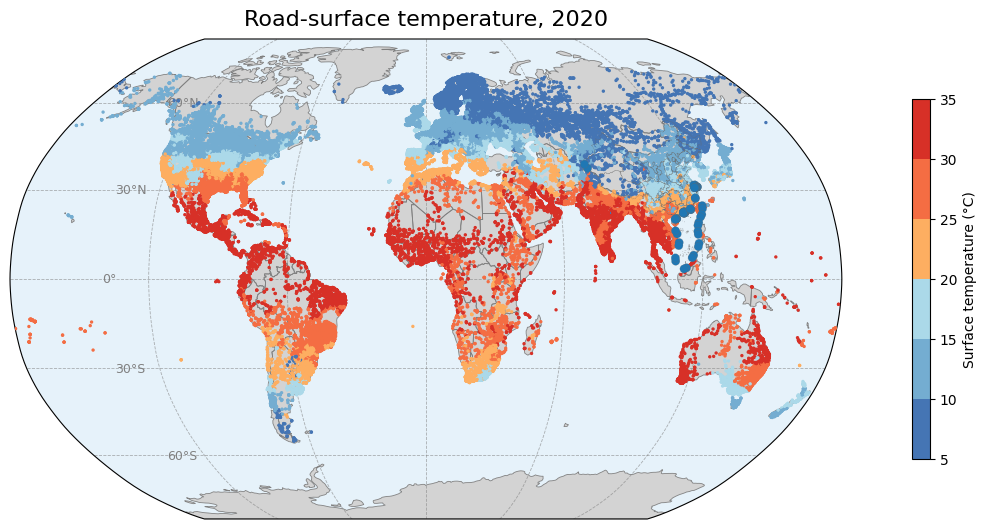

In [6]:
def add_latitude_labels(ax, x=-140):
    for lat in [-60, -30, 0, 30, 60]:
        label = f"{abs(lat)}°S" if lat < 0 else (f"{lat}°N" if lat > 0 else "0°")
        ax.text(x, lat, label, transform=ccrs.PlateCarree(),
                fontsize=9, va="center", ha="left", color="gray", clip_on=False)

fig = plt.figure(figsize=(12, 6))
ax = fig.add_axes([0.05, 0.1, 0.75, 0.8], projection=ccrs.Robinson())
ax.set_global()
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="#e6f2fa")
ax.gridlines(xlocs=np.arange(-180, 181, 60), ylocs=[-60, -30, 0, 30, 60],
             linestyle="--", linewidth=0.6, color="gray", alpha=0.6)
add_latitude_labels(ax)

sc = ax.scatter(merged["lon"], merged["lat"], c=merged["temp"], cmap=cmap, norm=norm,
                s=2, transform=ccrs.PlateCarree(), zorder=3)

world.boundary.plot(ax=ax, linewidth=0.6, edgecolor="gray", transform=ccrs.PlateCarree())
china.boundary.plot(ax=ax, linewidth=0.2, edgecolor="dimgray", linestyle="--",
                    transform=ccrs.PlateCarree(), zorder=4)

ax.set_title("Road-surface temperature, 2020", fontsize=16, pad=10)

cax = fig.add_axes([0.83, 0.2, 0.015, 0.6])
cb = plt.colorbar(sc, cax=cax, ticks=levels)
cb.set_label("Surface temperature (°C)")
plt.show()

```{admonition} Deliverable
:class: note
A global road-surface-temperature scatter map on a Robinson projection, with a binned
colour scale and country/province boundaries.
```
